Dataset Shape: (150, 5)

First 5 Rows:

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Statistical Summary:

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   1

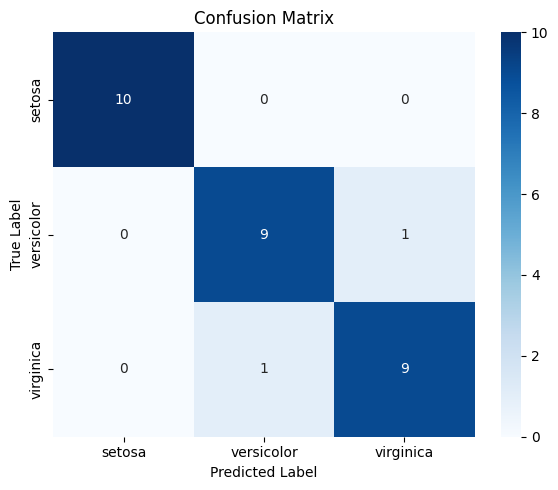

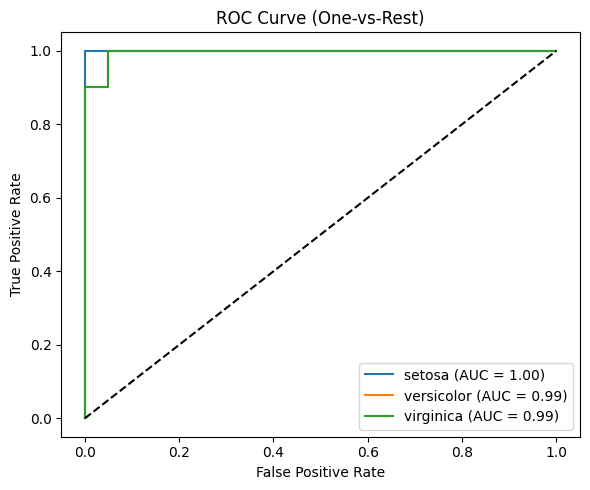

<Figure size 800x500 with 0 Axes>

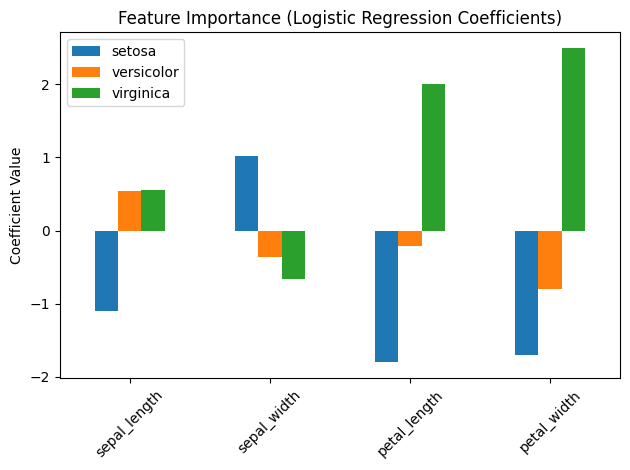


Logistic Regression Classification Task Completed Successfully.


In [ ]:

# Level 2 - Task 2: Classification with Logistic Regression


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize


# 1. Load Dataset


df = pd.read_csv("../datasets/iris.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n")
print(df.head())

print("\nDataset Information:\n")
print(df.info())

print("\nStatistical Summary:\n")
print(df.describe())


# 2. Define Features and Target


X = df.drop("species", axis=1)
y = df["species"]


# 3. Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 4. Feature Scaling


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 5. Train Logistic Regression Model


model = LogisticRegression(max_iter=300)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


# 6. Evaluation Metrics


print("\nModel Performance:")
print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# VISUALIZATIONS (Clean & Professional)



# 1. Confusion Matrix


plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



# 2. ROC Curve (One-vs-Rest)


y_test_bin = label_binarize(y_test, classes=model.classes_)
y_prob = model.predict_proba(X_test_scaled)

plt.figure(figsize=(6,5))

for i in range(len(model.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()



# 3. Feature Importance (Model Coefficients)


coef_df = pd.DataFrame(model.coef_,
                       columns=X.columns,
                       index=model.classes_)

plt.figure(figsize=(8,5))
coef_df.T.plot(kind="bar")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("\nLogistic Regression Classification Task Completed Successfully.")